# Topological Feature Extraction Demo

Bu notebook persistent homology kullanarak time series'lerden topological feature çıkarımını adım adım gösterir.

**Pipeline:**
1. Time Series yükleme ve görselleştirme
2. Takens Embedding (1D → 3D point cloud)
3. Persistent Homology (Ripser)
4. Persistence Diagram çizimi
5. Persistence Landscape hesaplama ve çizimi
6. **Mean Landscape karşılaştırma** (NEW)
7. Feature vector extraction
8. Birden fazla series için batch processing

**Environment:** Python (ts-top)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from ripser import ripser
from topological_features import TopologicalFeatureExtractor

# Plotting settings
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✓ Imports successful")

✓ Imports successful


## 1. Veri Yükleme

In [3]:
data_path = Path("../data/raw/unified-5k/stationary/ar/long.parquet")

if not data_path.exists():
    print(f"⚠ Dosya bulunamadı: {data_path}")
else:
    df = pd.read_parquet(data_path)
    print(f"✓ Dosya yüklendi: {data_path.name}")
    print(f"  Shape: {df.shape}")
    print(f"  Toplam series: {df['series_id'].nunique()}")
    display(df.head())

✓ Dosya yüklendi: long.parquet
  Shape: (3438713, 56)
  Toplam series: 630


,series_id,time,data,length,is_stationary,primary_category,sub_category,base_series,base_process_type,order,...,location_point,location_collective,location_mean_shift,location_variance_shift,location_trend_shift,location_contextual,noise_type,noise_std,sampling_frequency,label
0,1,0,0.618411,8270,1,stationary,ar,ar,None,(3),...,None,None,None,None,None,None,None,None,None,ar_long
1,1,1,-1.041652,8270,1,stationary,ar,ar,None,(3),...,None,None,None,None,None,None,None,None,None,ar_long
2,1,2,-0.754603,8270,1,stationary,ar,ar,None,(3),...,None,None,None,None,None,None,None,None,None,ar_long
3,1,3,-0.403297,8270,1,stationary,ar,ar,None,(3),...,None,None,None,None,None,None,None,None,None,ar_long
4,1,4,-0.447987,8270,1,stationary,ar,ar,None,(3),...,None,None,None,None,None,None,None,None,None,ar_long


## 2. Time Series Seçimi ve Görselleştirme

Series ID: 1
Length: 8270


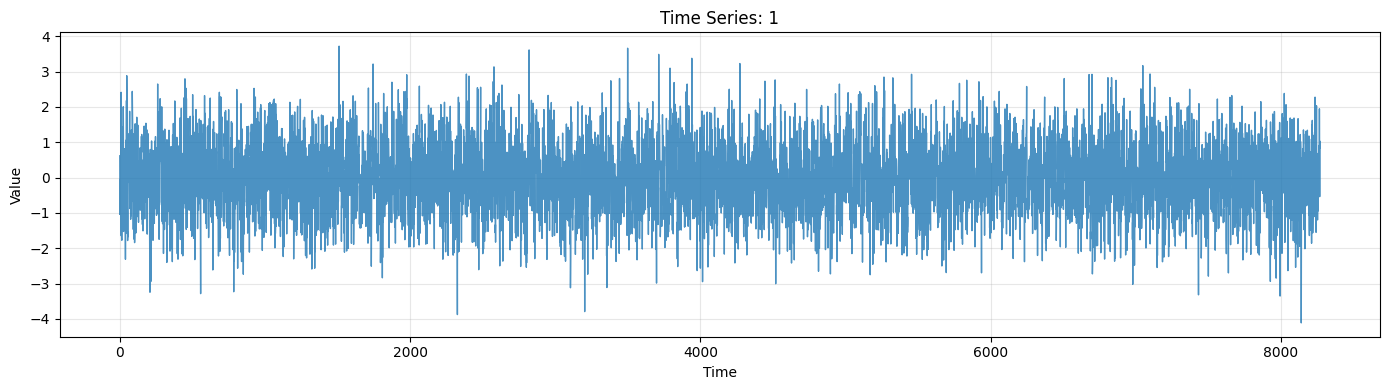

In [4]:
series_id = df['series_id'].iloc[0]
series_data = df[df['series_id'] == series_id]
time_series = series_data['data'].values

print(f"Series ID: {series_id}")
print(f"Length: {len(time_series)}")

plt.figure(figsize=(14, 4))
plt.plot(time_series, linewidth=1, alpha=0.8)
plt.title(f"Time Series: {series_id}")
plt.xlabel("Time")
plt.ylabel("Value")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Takens Embedding

Point cloud shape: (8268, 3)


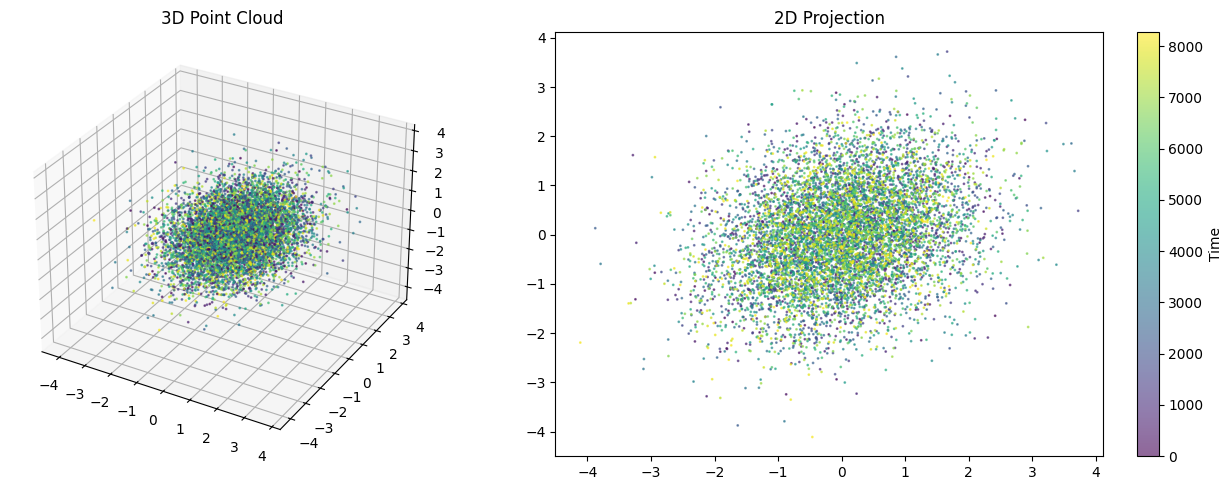

In [5]:
extractor = TopologicalFeatureExtractor(
    embedding_dim=3,
    embedding_delay=1,
    homology_dims=(0, 1),
    n_landscapes=5,
    landscape_resolution=100,
    normalize=True,
    n_perm=500
)

point_cloud = extractor.takens_embedding(time_series)
print(f"Point cloud shape: {point_cloud.shape}")

fig = plt.figure(figsize=(14, 5))
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(point_cloud[:, 0], point_cloud[:, 1], point_cloud[:, 2], 
           c=np.arange(len(point_cloud)), cmap='viridis', s=1, alpha=0.6)
ax1.set_title('3D Point Cloud')

ax2 = fig.add_subplot(122)
scatter = ax2.scatter(point_cloud[:, 0], point_cloud[:, 1], 
                     c=np.arange(len(point_cloud)), cmap='viridis', s=1, alpha=0.6)
ax2.set_title('2D Projection')
plt.colorbar(scatter, ax=ax2, label='Time')
plt.tight_layout()
plt.show()

## 4. Persistent Homology (Ripser)

In [6]:
diagrams = extractor.compute_persistence_diagrams(time_series)

print("Persistence Diagrams:")
for dim, diagram in diagrams.items():
    finite_diagram = diagram[np.isfinite(diagram).all(axis=1)]
    print(f"  H{dim}: {len(finite_diagram)} pairs")
    if len(finite_diagram) > 0:
        lifetimes = finite_diagram[:, 1] - finite_diagram[:, 0]
        print(f"    Lifetime: mean={lifetimes.mean():.3f}, max={lifetimes.max():.3f}")

Persistence Diagrams:
  H0: 499 pairs
    Lifetime: mean=0.627, max=1.260
  H1: 408 pairs
    Lifetime: mean=0.107, max=0.366


## 5. Persistence Diagram Görselleştirme

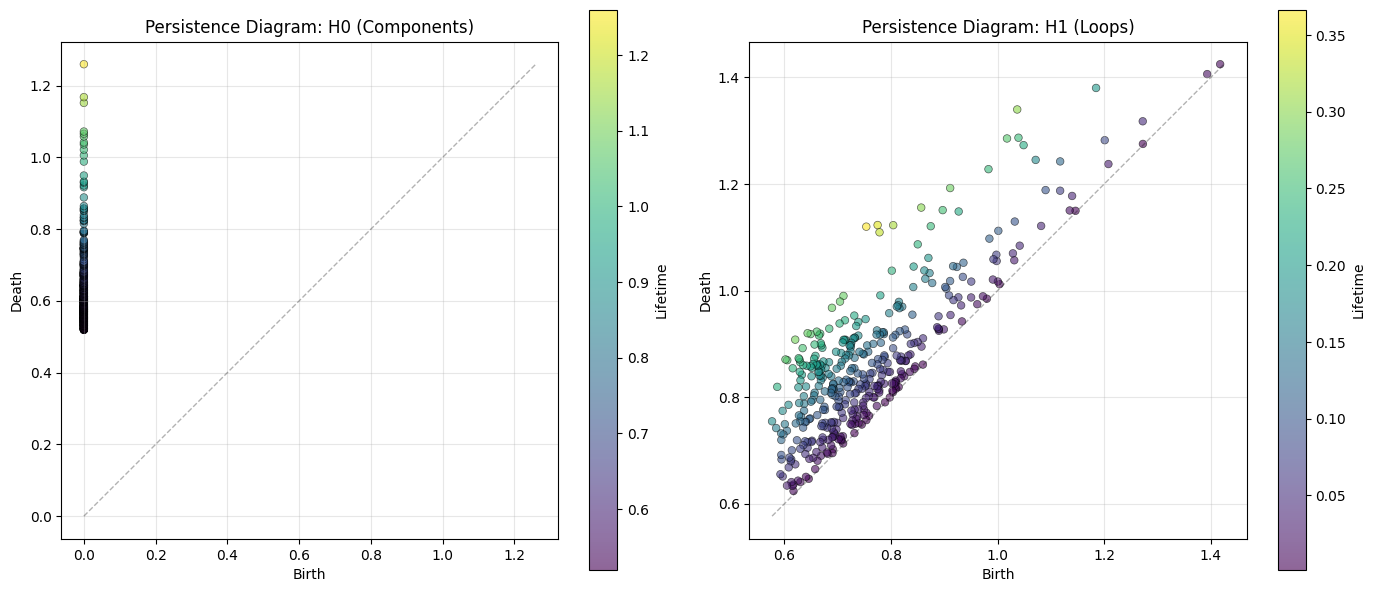

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
labels = {0: 'H0 (Components)', 1: 'H1 (Loops)'}

for idx, (dim, diagram) in enumerate(diagrams.items()):
    ax = axes[idx]
    finite_diagram = diagram[np.isfinite(diagram).all(axis=1)]
    
    if len(finite_diagram) > 0:
        births = finite_diagram[:, 0]
        deaths = finite_diagram[:, 1]
        lifetimes = deaths - births
        
        scatter = ax.scatter(births, deaths, c=lifetimes, cmap='viridis', 
                           s=30, alpha=0.6, edgecolors='black', linewidth=0.5)
        
        max_val = max(deaths.max(), births.max())
        min_val = min(deaths.min(), births.min())
        ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.3, linewidth=1)
        
        ax.set_xlabel('Birth')
        ax.set_ylabel('Death')
        ax.set_title(f'Persistence Diagram: {labels[dim]}')
        ax.grid(True, alpha=0.3)
        ax.set_aspect('equal')
        plt.colorbar(scatter, ax=ax, label='Lifetime')

plt.tight_layout()
plt.show()

## 6. Persistence Landscape Hesaplama

Her homology dimension için 5 landscape hesaplayacağız.

In [8]:
landscape_data = {}

for dim, diagram in diagrams.items():
    landscape_vector = extractor.compute_persistence_landscape(diagram)
    landscape_matrix = landscape_vector.reshape(extractor.n_landscapes, extractor.landscape_resolution)
    landscape_data[dim] = landscape_matrix
    
    print(f"H{dim} Landscape:")
    print(f"  Shape: {landscape_matrix.shape}")
    print(f"  Non-zero: {np.count_nonzero(landscape_vector)}/{len(landscape_vector)}")

H0 Landscape:
  Shape: (5, 100)
  Non-zero: 446/500
H1 Landscape:
  Shape: (5, 100)
  Non-zero: 430/500


## 7. Landscape Görselleştirme: Individual vs Mean

### 7.1 Tüm Landscape'ler (λ₁, λ₂, λ₃, λ₄, λ₅)

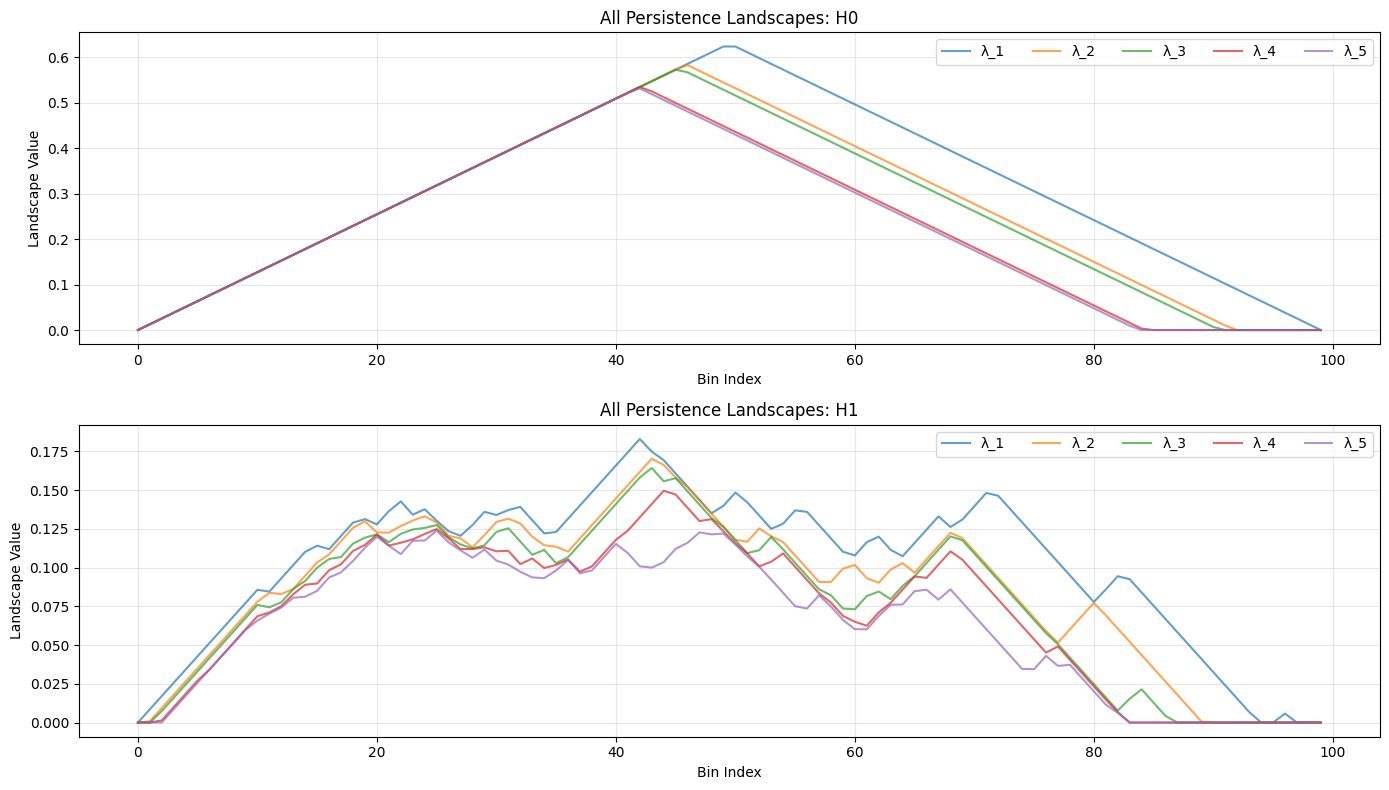

✓ Tüm landscape'ler çizildi


In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

for idx, (dim, landscape_matrix) in enumerate(landscape_data.items()):
    ax = axes[idx]
    x = np.arange(extractor.landscape_resolution)
    
    # Her landscape'i ayrı çiz
    for k in range(extractor.n_landscapes):
        ax.plot(x, landscape_matrix[k, :], label=f'λ_{k+1}', alpha=0.7, linewidth=1.5)
    
    ax.set_xlabel('Bin Index')
    ax.set_ylabel('Landscape Value')
    ax.set_title(f'All Persistence Landscapes: H{dim}')
    ax.legend(loc='upper right', ncol=5)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Tüm landscape'ler çizildi")

### 7.2 Mean Landscape Karşılaştırma (NEW)

5 landscape'in ortalamasını alarak daha compact bir representation elde ediyoruz.

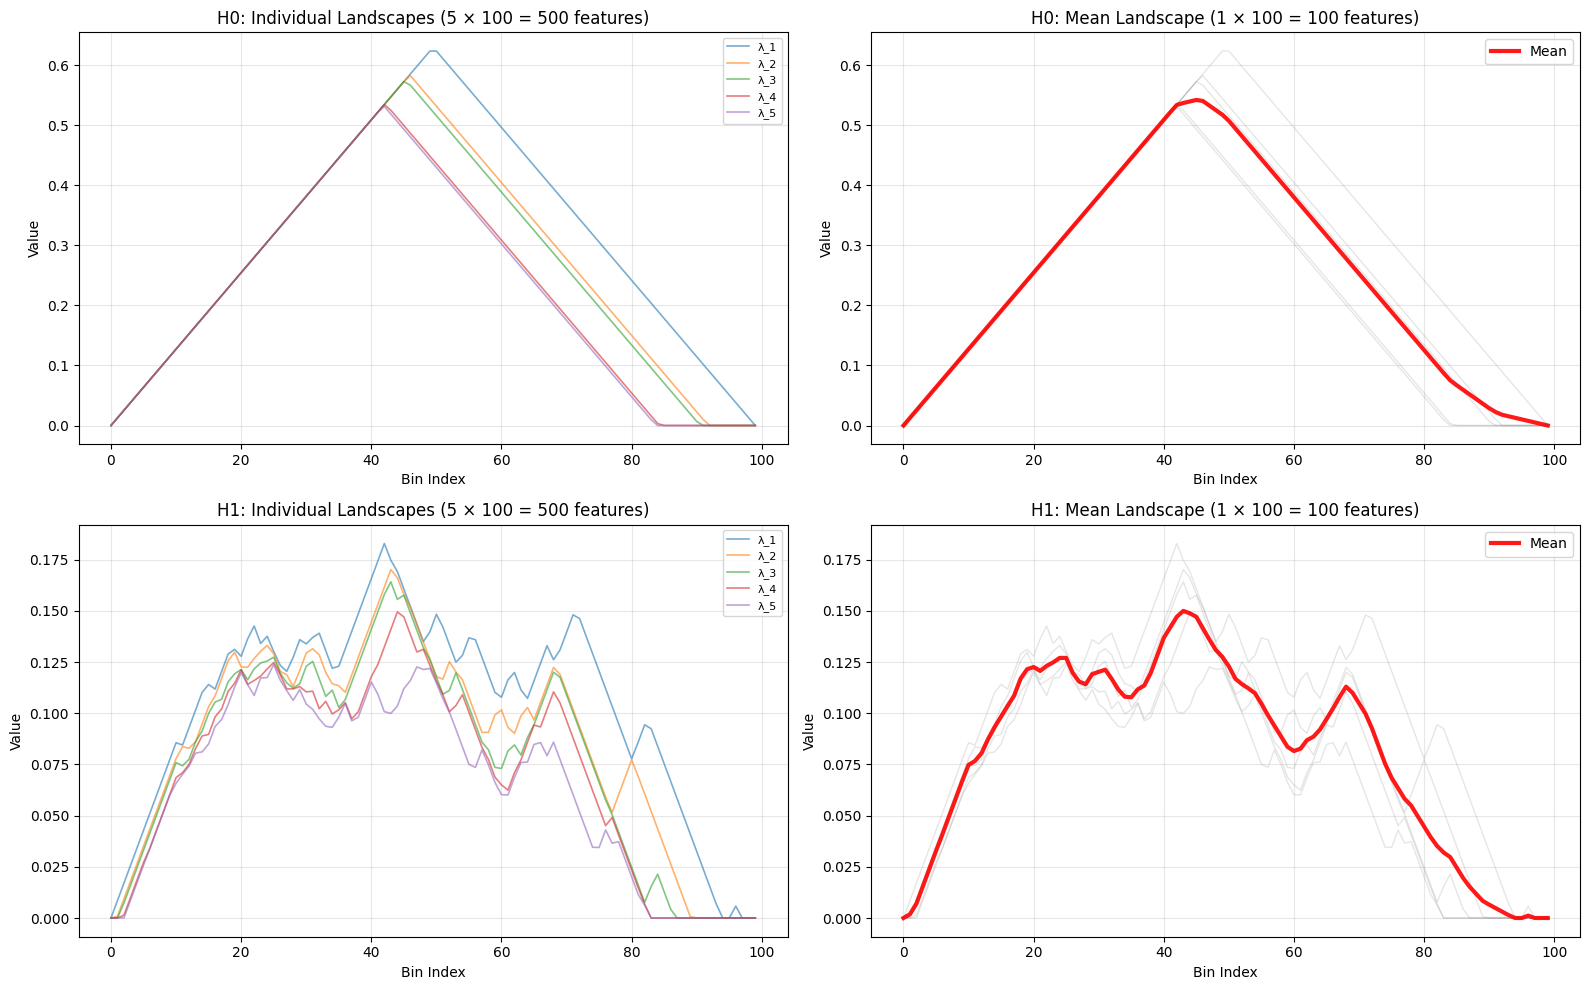


✓ Individual vs Mean landscape karşılaştırma
  Normal mode: 2 × 5 × 100 = 1000 features
  Mean mode:   2 × 1 × 100 = 200 features
  Reduction: 80.0%


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for idx, (dim, landscape_matrix) in enumerate(landscape_data.items()):
    # Sol: Tüm landscapes
    ax_left = axes[idx, 0]
    x = np.arange(extractor.landscape_resolution)
    
    for k in range(extractor.n_landscapes):
        ax_left.plot(x, landscape_matrix[k, :], label=f'λ_{k+1}', alpha=0.6, linewidth=1.2)
    
    ax_left.set_xlabel('Bin Index')
    ax_left.set_ylabel('Value')
    ax_left.set_title(f'H{dim}: Individual Landscapes (5 × 100 = 500 features)')
    ax_left.legend(loc='upper right', fontsize=8)
    ax_left.grid(True, alpha=0.3)
    
    # Sağ: Mean landscape
    ax_right = axes[idx, 1]
    mean_landscape = landscape_matrix.mean(axis=0)
    
    # Tüm landscape'leri shadow olarak göster
    for k in range(extractor.n_landscapes):
        ax_right.plot(x, landscape_matrix[k, :], alpha=0.2, linewidth=1, color='gray')
    
    # Mean'i kalın çiz
    ax_right.plot(x, mean_landscape, label='Mean', color='red', linewidth=3, alpha=0.9)
    
    ax_right.set_xlabel('Bin Index')
    ax_right.set_ylabel('Value')
    ax_right.set_title(f'H{dim}: Mean Landscape (1 × 100 = 100 features)')
    ax_right.legend(loc='upper right')
    ax_right.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Individual vs Mean landscape karşılaştırma")
print(f"  Normal mode: {len(diagrams)} × {extractor.n_landscapes} × {extractor.landscape_resolution} = {len(diagrams) * extractor.n_landscapes * extractor.landscape_resolution} features")
print(f"  Mean mode:   {len(diagrams)} × 1 × {extractor.landscape_resolution} = {len(diagrams) * extractor.landscape_resolution} features")
print(f"  Reduction: {100 - (len(diagrams) * extractor.landscape_resolution) / (len(diagrams) * extractor.n_landscapes * extractor.landscape_resolution) * 100:.1f}%")

### 7.3 Feature Statistics: Normal vs Mean

In [11]:
# Normal extractor
features_normal = extractor.extract_features(time_series)

# Mean extractor
extractor_mean = TopologicalFeatureExtractor(
    embedding_dim=3,
    embedding_delay=1,
    homology_dims=(0, 1),
    n_landscapes=5,
    landscape_resolution=100,
    normalize=True,
    use_mean_landscape=True,
    n_perm=500
)
features_mean = extractor_mean.extract_features(time_series)

print("Feature Statistics:")
print(f"\nNormal mode:")
print(f"  Shape: {features_normal.shape}")
print(f"  Range: [{features_normal.min():.3f}, {features_normal.max():.3f}]")
print(f"  Non-zero: {np.count_nonzero(features_normal)}")

print(f"\nMean mode:")
print(f"  Shape: {features_mean.shape}")
print(f"  Range: [{features_mean.min():.3f}, {features_mean.max():.3f}]")
print(f"  Non-zero: {np.count_nonzero(features_mean)}")

print(f"\n✓ Feature reduction: {len(features_normal)} → {len(features_mean)} ({len(features_mean)/len(features_normal)*100:.1f}%)")

Feature Statistics:

Normal mode:
  Shape: (1000,)
  Range: [0.000, 1.000]
  Non-zero: 876

Mean mode:
  Shape: (200,)
  Range: [0.000, 1.000]
  Non-zero: 192

✓ Feature reduction: 1000 → 200 (20.0%)


### 7.4 Feature Vector Comparison

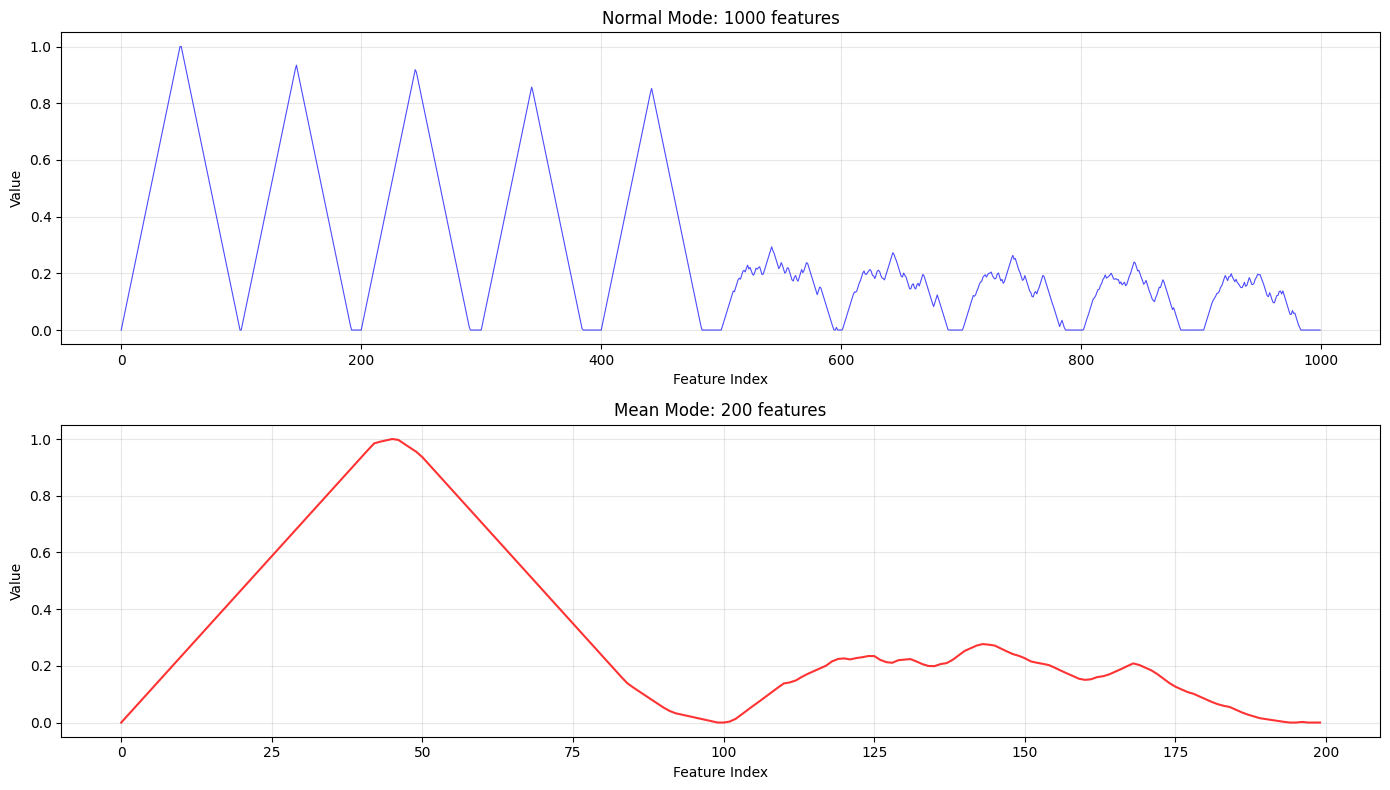

✓ Feature vectors karşılaştırıldı


In [12]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Normal features
axes[0].plot(features_normal, linewidth=0.8, alpha=0.7, color='blue')
axes[0].set_xlabel('Feature Index')
axes[0].set_ylabel('Value')
axes[0].set_title(f'Normal Mode: {len(features_normal)} features')
axes[0].grid(True, alpha=0.3)

# Mean features
axes[1].plot(features_mean, linewidth=1.5, alpha=0.8, color='red')
axes[1].set_xlabel('Feature Index')
axes[1].set_ylabel('Value')
axes[1].set_title(f'Mean Mode: {len(features_mean)} features')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Feature vectors karşılaştırıldı")

## 8. Birden Fazla Series için Batch Processing

In [13]:
unique_ids = df['series_id'].unique()[:2]
print(f"Seçilen series: {unique_ids}")

series_dict = {}
series_metadata = {}

for sid in unique_ids:
    series_data = df[df['series_id'] == sid]
    series_dict[sid] = series_data['data'].values
    series_metadata[sid] = {
        'is_stationary': series_data['is_stationary'].iloc[0],
        'primary_category': series_data['primary_category'].iloc[0],
        'sub_category': series_data['sub_category'].iloc[0]
    }

Seçilen series: [1 2]


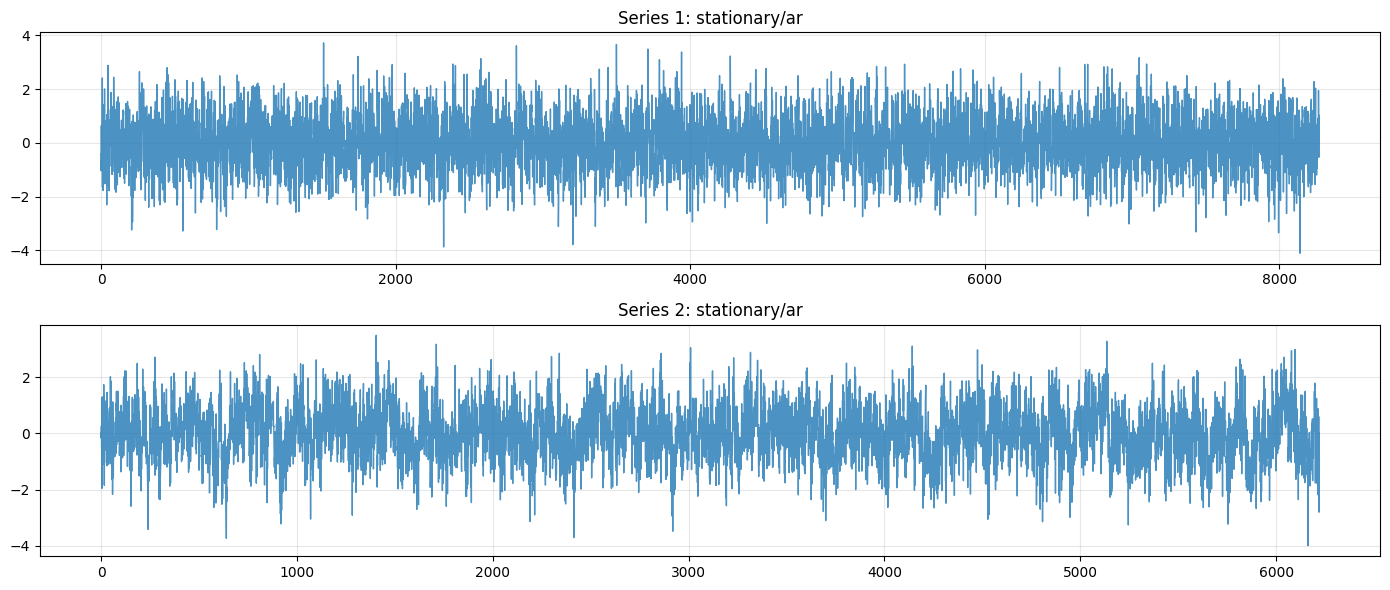

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

for idx, (sid, ts) in enumerate(series_dict.items()):
    ax = axes[idx]
    meta = series_metadata[sid]
    ax.plot(ts, linewidth=1, alpha=0.8)
    ax.set_title(f"Series {sid}: {meta['primary_category']}/{meta['sub_category']}")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 8.1 Batch Extraction: Normal vs Mean

In [15]:
# Normal mode
print("Normal mode extraction...")
features_df_normal, failed = extractor.extract_batch(series_dict, n_jobs=1, verbose=True)
print(f"  ✓ {features_df_normal.shape[0]} series, {features_df_normal.shape[1]-1} features")

# Mean mode
print("\nMean mode extraction...")
features_df_mean, failed = extractor_mean.extract_batch(series_dict, n_jobs=1, verbose=True)
print(f"  ✓ {features_df_mean.shape[0]} series, {features_df_mean.shape[1]-1} features")

Normal mode extraction...
  Processing 2 series with 1 jobs...


  Extracting features: 100%|██████████| 2/2 [00:00<00:00,  2.21it/s]


  ✓ 2 series, 1000 features

Mean mode extraction...
  Processing 2 series with 1 jobs...


  Extracting features: 100%|██████████| 2/2 [00:00<00:00,  2.35it/s]

  ✓ 2 series, 200 features


## 9. Final DataFrame: Features + Metadata

In [16]:
metadata_df = pd.DataFrame.from_dict(series_metadata, orient='index')
metadata_df.index.name = 'series_id'
metadata_df = metadata_df.reset_index()

# Normal mode DataFrame
final_df_normal = features_df_normal.merge(metadata_df, on='series_id', how='left')
metadata_cols = ['series_id', 'is_stationary', 'primary_category', 'sub_category']
feature_cols_normal = [col for col in final_df_normal.columns if col.startswith('topo_')]
final_df_normal = final_df_normal[metadata_cols + feature_cols_normal]

# Mean mode DataFrame
final_df_mean = features_df_mean.merge(metadata_df, on='series_id', how='left')
feature_cols_mean = [col for col in final_df_mean.columns if col.startswith('topo_')]
final_df_mean = final_df_mean[metadata_cols + feature_cols_mean]

print(f"{'='*80}")
print(f"FINAL DATAFRAMES COMPARISON")
print(f"{'='*80}")
print(f"\nNormal mode:")
print(f"  Shape: {final_df_normal.shape}")
print(f"  Metadata: {len(metadata_cols)}, Features: {len(feature_cols_normal)}")
display(final_df_normal.head())

print(f"\nMean mode:")
print(f"  Shape: {final_df_mean.shape}")
print(f"  Metadata: {len(metadata_cols)}, Features: {len(feature_cols_mean)}")
display(final_df_mean.head())

FINAL DATAFRAMES COMPARISON

Normal mode:
  Shape: (2, 1004)
  Metadata: 4, Features: 1000


,series_id,is_stationary,primary_category,sub_category,topo_H0_L0_bin0,topo_H0_L0_bin1,topo_H0_L0_bin2,topo_H0_L0_bin3,topo_H0_L0_bin4,topo_H0_L0_bin5,...,topo_H1_L4_bin90,topo_H1_L4_bin91,topo_H1_L4_bin92,topo_H1_L4_bin93,topo_H1_L4_bin94,topo_H1_L4_bin95,topo_H1_L4_bin96,topo_H1_L4_bin97,topo_H1_L4_bin98,topo_H1_L4_bin99
0,1,1,stationary,ar,0.0,0.020408,0.040816,0.061224,0.081633,0.102041,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,1,stationary,ar,0.0,0.020408,0.040816,0.061224,0.081633,0.102041,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Mean mode:
  Shape: (2, 204)
  Metadata: 4, Features: 200


,series_id,is_stationary,primary_category,sub_category,topo_H0_mean_bin0,topo_H0_mean_bin1,topo_H0_mean_bin2,topo_H0_mean_bin3,topo_H0_mean_bin4,topo_H0_mean_bin5,...,topo_H1_mean_bin90,topo_H1_mean_bin91,topo_H1_mean_bin92,topo_H1_mean_bin93,topo_H1_mean_bin94,topo_H1_mean_bin95,topo_H1_mean_bin96,topo_H1_mean_bin97,topo_H1_mean_bin98,topo_H1_mean_bin99
0,1,1,stationary,ar,0.0,0.023473,0.046946,0.070418,0.093891,0.117364,...,0.012004,0.008844,0.005683,0.002523,0.000000,0.000000,0.002137,0.000000,0.000000,0.0
1,2,1,stationary,ar,0.0,0.025851,0.051703,0.077554,0.103405,0.129257,...,0.000000,0.000000,0.000000,0.000000,0.000143,0.004145,0.008146,0.008003,0.004002,0.0


## 10. Feature Comparison

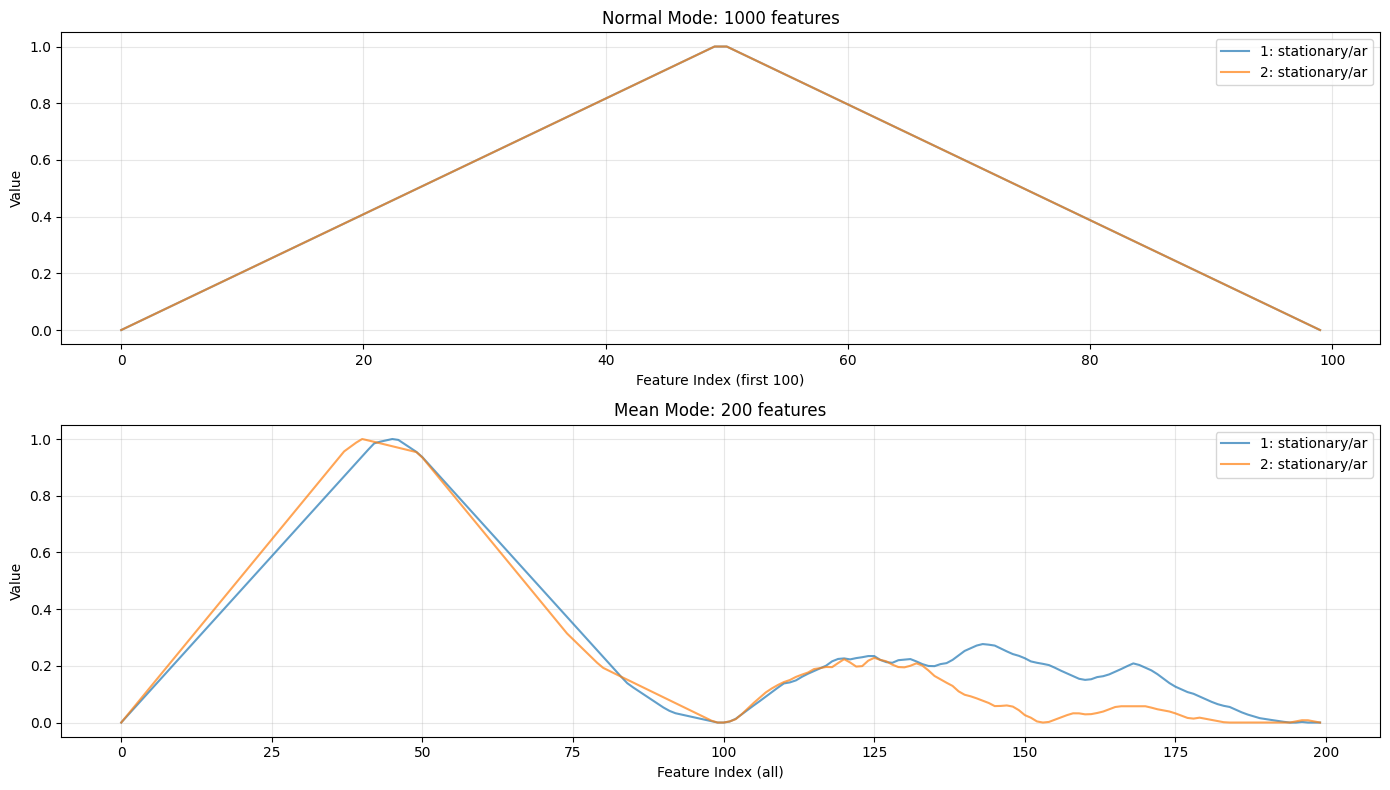

✓ Karşılaştırma tamamlandı


In [17]:
n_plot = 100

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Normal mode
ax = axes[0]
for idx, row in final_df_normal.iterrows():
    label = f"{row['series_id']}: {row['primary_category']}/{row['sub_category']}"
    ax.plot(row[feature_cols_normal[:n_plot]].values, label=label, alpha=0.7, linewidth=1.5)
ax.set_xlabel(f'Feature Index (first {n_plot})')
ax.set_ylabel('Value')
ax.set_title(f'Normal Mode: {len(feature_cols_normal)} features')
ax.legend()
ax.grid(True, alpha=0.3)

# Mean mode
ax = axes[1]
for idx, row in final_df_mean.iterrows():
    label = f"{row['series_id']}: {row['primary_category']}/{row['sub_category']}"
    ax.plot(row[feature_cols_mean].values, label=label, alpha=0.7, linewidth=1.5)
ax.set_xlabel('Feature Index (all)')
ax.set_ylabel('Value')
ax.set_title(f'Mean Mode: {len(feature_cols_mean)} features')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Karşılaştırma tamamlandı")

---

## Summary

**Tamamlanan adımlar:**
1. Time series yükleme ve görselleştirme
2. Takens embedding (1D → 3D)
3. Persistent homology (Ripser)
4. Persistence diagram çizimi
5. Persistence landscape hesaplama
6. **Individual vs Mean landscape karşılaştırma** (NEW)
7. Feature vector extraction (Normal & Mean)
8. Batch processing
9. Final DataFrame

### **Mean Landscape Özeti:**

| Mode | Features | Avantaj | Dezavantaj |
|------|----------|---------|------------|
| **Normal** | 1000 | Tam detay, yüksek accuracy | Çok feature, yavaş training |
| **Mean** | 200 | Compact, hızlı, robust | Detay kaybı |

**Öneri:** İlk denemelerde mean landscape kullanın, accuracy yeterliyse devam edin!